In [ ]:
import pandas as pd
# path_to_csv = 'combined_data_metawear.csv'   # This will be the combined dataset, just one large csv file
# df = pd.read_csv(path_to_csv)       # Change variable to your csv file
# print(df.shape)
# df.head()

In [ ]:
import tensorflow as tf
tf.test.gpu_device_name()

2026-04-07 17:51:13.147144: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-07 17:51:13.147315: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-07 17:51:13.147320: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-07 17:51:13.147692: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-07 17:51:13.147705: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


'/device:GPU:0'

In [ ]:
from google.colab import files

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
uploaded = files.upload()

Saving combined_data_metawear.csv to combined_data_metawear.csv


In [ ]:
df = pd.read_csv('combined_data_metawear.csv')
print(df.shape)
df.head()

(1382240, 7)


,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,label
0,-0.981,0.102,-0.167,-0.061,5.732,5.549,1
1,-0.985,0.108,-0.170,-0.671,5.671,4.451,1
2,-0.985,0.114,-0.177,-1.646,4.878,4.390,1
3,-1.001,0.125,-0.184,-2.012,5.061,3.598,1
4,-1.011,0.136,-0.189,-1.768,6.037,2.439,1


In [ ]:
# import io
# df = pd.read_csv(io.BytesIO(uploaded['combined_data_metawear.csv']))
# print(df.shape)
# df.head()


In [ ]:
random_seed = 42
n_time_steps = 100
n_features = 6
step = 10
n_classes = 5
n_epochs = 400
batch_size = 128
learning_rate = 0.01
l2_loss = 0.0015
#momentum = 0.9

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
segments = []
labels = []

for i in range(0,  df.shape[0]- n_time_steps, step):

    acc_x = df['acc_x'].values[i: i + 100]

    acc_y = df['acc_y'].values[i: i + 100]

    acc_z = df['acc_z'].values[i: i + 100]

    gyr_x = df['gyr_x'].values[i: i + 100]

    gyr_y = df['gyr_y'].values[i: i + 100]

    gyr_z = df['gyr_z'].values[i: i + 100]

    label = stats.mode(df['label'][i: i + 100])[0][0]

    segments.append([acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z])

    labels.append(label)

#reshape the segments which is (list of arrays) to a list
reshaped_segments = np.asarray(segments, dtype= np.float32).reshape(-1, n_time_steps, n_features)

labels = np.asarray(pd.get_dummies(labels), dtype = np.float32)

In [ ]:
reshaped_segments.shape

(138214, 100, 6)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(reshaped_segments, labels, test_size = 0.2, random_state = random_seed)

In [ ]:
X_train.shape

(110571, 100, 6)

In [ ]:
X_test.shape

(27643, 100, 6)

In [ ]:
y_test.shape

(27643, 5)

In [ ]:
y_train.shape

(110571, 5)

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Flatten, Dropout
from sklearn.model_selection import GridSearchCV


In [ ]:
from tensorflow.keras.optimizers import Adam

model = Sequential()
# RNN layer
model.add(LSTM(128, return_sequences=True,input_shape = (X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.5))
# Dropout layer
#model.add(Dropout(0.5))
# Dense layer with ReLu
model.add(Dense(units = 64, activation='relu'))
# Softmax layer
model.add(Dense(y_train.shape[1], activation = 'softmax'))
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


   # return model


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 128)          69120     
                                                                 
 dropout (Dropout)           (None, 100, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 128)          131584    
                                                                 
 dropout_1 (Dropout)         (None, 100, 128)          0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8

In [ ]:
# from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
# es = EarlyStopping(monitor='val_loss', mode='min', verbose=1)

In [ ]:
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

In [ ]:
history = model.fit(X_train, y_train, epochs = n_epochs, validation_data = (X_test, y_test), batch_size = batch_size, verbose = 1)

Epoch 1/400
864/864 [==============================] - 34s 29ms/step - loss: 1.5868 - accuracy: 0.2519 - val_loss: 1.5485 - val_accuracy: 0.2906
Epoch 2/400
864/864 [==============================] - 21s 25ms/step - loss: 1.5335 - accuracy: 0.2949 - val_loss: 1.4814 - val_accuracy: 0.3350
Epoch 3/400
864/864 [==============================] - 22s 25ms/step - loss: 1.4464 - accuracy: 0.3596 - val_loss: 1.3604 - val_accuracy: 0.4166
Epoch 4/400
864/864 [==============================] - 22s 25ms/step - loss: 1.2812 - accuracy: 0.4628 - val_loss: 1.1830 - val_accuracy: 0.5134
Epoch 5/400
864/864 [==============================] - 23s 26ms/step - loss: 1.1276 - accuracy: 0.5442 - val_loss: 1.0289 - val_accuracy: 0.5884
Epoch 6/400
864/864 [==============================] - 23s 26ms/step - loss: 1.0036 - accuracy: 0.6033 - val_loss: 0.9225 - val_accuracy: 0.6369
Epoch 7/400
864/864 [==============================] - 22s 25ms/step - loss: 0.8953 - accuracy: 0.6512 - val_loss: 0.8102 - val_ac

In [ ]:
from keras.models import load_model

model.save('best_model.h5')  # creates a HDF5 file 'my_model.h5'
#del model  # deletes the existing model

# returns a compiled model
# identical to the previous one
model = load_model('best_model.h5')


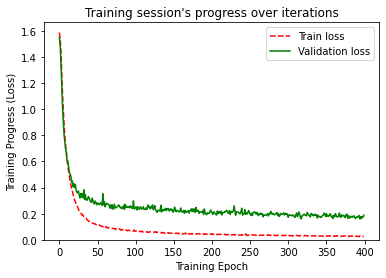

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(np.array(history.history['loss']), "r--", label = "Train loss")
#plt.plot(np.array(history.history['accuracy']), "g--", label = "Train accuracy")
plt.plot(np.array(history.history['val_loss']), "g-", label = "Validation loss")
#plt.plot(np.array(history.history['val_accuracy']), "g-", label = "Validation accuracy")
plt.title("Training session's progress over iterations")
plt.legend(loc='upper right')
plt.ylabel('Training Progress (Loss)')
plt.xlabel('Training Epoch')
plt.ylim(0)
plt.show()
plt.savefig('LSTM_graph.png', dpi=300)

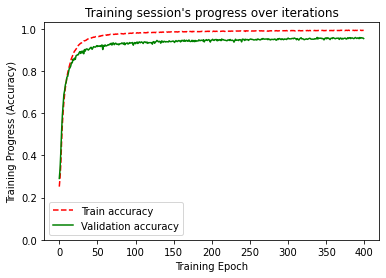

<Figure size 432x288 with 0 Axes>

In [ ]:
#plt.plot(np.array(history.history['loss']), "r--", label = "Train loss")
plt.plot(np.array(history.history['accuracy']), "r--", label = "Train accuracy")
#plt.plot(np.array(history.history['val_loss']), "g-", label = "Validation loss")
plt.plot(np.array(history.history['val_accuracy']), "g-", label = "Validation accuracy")
plt.title("Training session's progress over iterations")
plt.legend(loc='lower left')
plt.ylabel('Training Progress (Accuracy)')
plt.xlabel('Training Epoch')
plt.ylim(0)
plt.show()
plt.savefig('LSTM_graph.png', dpi=300)

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size = batch_size, verbose = 1)
print("Test Accuracy : %.3f" % (test_accuracy))
print("Test Loss :%.3f" % (test_loss))

train_loss, train_accuracy = model.evaluate(X_train, y_train, batch_size = batch_size, verbose = 1)
print("Train Accuracy : %.3f" % (train_accuracy))
print("Train Loss :%.3f" % (train_loss))

#_, train_acc = model.evaluate(X_train, y_train, verbose=0)
#_, test_acc = model.evaluate(X_test, y_test, verbose=0)
#print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

216/216 [==============================] - 3s 10ms/step - loss: 0.1884 - accuracy: 0.9532
Test Accuracy : 0.953
Test Loss :0.188
864/864 [==============================] - 8s 10ms/step - loss: 0.0112 - accuracy: 0.9972
Train Accuracy : 0.997
Train Loss :0.011


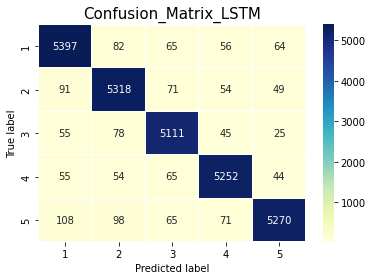

<Figure size 432x288 with 0 Axes>

In [ ]:
import sklearn.metrics as metrics
predictions = model.predict(X_test)
class_labels = [1,2,3,4,5]
max_test = np.argmax(y_test, axis=1)
max_predictions = np.argmax(predictions, axis = 1)
confusion_matrix = metrics.confusion_matrix(max_test, max_predictions)
sns.heatmap(confusion_matrix, xticklabels = class_labels, yticklabels = class_labels, annot = True, linewidths = 0.1, fmt='d', cmap = 'YlGnBu')
plt.title("Confusion_Matrix_LSTM", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
plt.savefig("(Confusion_Matrix_LSTM(epoch 400,80_20).png")

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
#cm = confusion_matrix((y_true, y_pred)
#print("Confusion Matrix:")
#print(cm)
result1 = classification_report(max_test, max_predictions)
print("Classification Report:")
print (result1)
result2 = accuracy_score(max_test, max_predictions)
print("Accuracy:",result2)

confusion_matrix = metrics.confusion_matrix(max_test, max_predictions)
print("Confusion Matrix:")
print(confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5664
           1       0.94      0.95      0.95      5583
           2       0.95      0.96      0.96      5314
           3       0.96      0.96      0.96      5470
           4       0.97      0.94      0.95      5612

    accuracy                           0.95     27643
   macro avg       0.95      0.95      0.95     27643
weighted avg       0.95      0.95      0.95     27643

Accuracy: 0.9531526968852874
Confusion Matrix:
[[5397   82   65   56   64]
 [  91 5318   71   54   49]
 [  55   78 5111   45   25]
 [  55   54   65 5252   44]
 [ 108   98   65   71 5270]]
